# Walmart Store Sales Forecasting — Exploratory Data Analysis (EDA)

**Kaggle competition:** [Walmart Recruiting - Store Sales Forecasting](https://www.kaggle.com/competitions/walmart-recruiting-store-sales-forecasting)

The goal of this notebook is a thorough exploration of `train.csv`, `test.csv`, `features.csv`, and `stores.csv` — trends, missing values, Holiday effects, and external factors — so that the next stage can do informed feature engineering and model selection (LightGBM, XGBoost, N-BEATS, TFT, DLinear, Prophet, ARIMA, TimesFM).

**Evaluation metric:** WMAE (Weighted Mean Absolute Error) — Holiday weeks get a weight of **x5** (all other weeks x1), per Kaggle's official rule.

## Table of Contents

1. [Data loading and merging](#1)
2. [Basic stats — shape, dtypes, missing values](#2)
3. [Target variable: Weekly_Sales](#3)
4. [Sales trends over time](#4)
5. [Holiday effects](#5)
6. [External features correlation](#6)
7. [MarkDown analysis](#7)
8. [Feature engineering ideas](#8)
9. [Conclusion](#9)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

DATA_DIR = 'data/raw/walmart-recruiting-store-sales-forecasting/'
pd.set_option('display.max_columns', 50)


<a id="1"></a>
## 1. Data Loading and Merging

Four files:

| File | Granularity | Description |
|---|---|---|
| `train.csv` | Store × Dept × Date | Weekly sales (target), 2010-02-05 → 2012-10-26 |
| `test.csv` | Store × Dept × Date | Forecast period, 2012-11-02 → 2013-07-26 |
| `stores.csv` | Store | Store Type (A/B/C) and Size |
| `features.csv` | Store × Date | Temperature, Fuel_Price, CPI, Unemployment, MarkDown1-5, IsHoliday |

`features.csv` has its own `IsHoliday` column, identical to the one in train/test — we avoid a duplicate when merging.

In [2]:
train = pd.read_csv(DATA_DIR + 'train.csv', parse_dates=['Date'])
test = pd.read_csv(DATA_DIR + 'test.csv', parse_dates=['Date'])
features = pd.read_csv(DATA_DIR + 'features.csv', parse_dates=['Date'])
stores = pd.read_csv(DATA_DIR + 'stores.csv')

print(f'train.csv    : {train.shape}')
print(f'test.csv     : {test.shape}')
print(f'features.csv : {features.shape}')
print(f'stores.csv   : {stores.shape}')


train.csv    : (421570, 5)
test.csv     : (115064, 4)
features.csv : (8190, 12)
stores.csv   : (45, 3)


In [3]:
# Check whether features.csv's IsHoliday matches train's IsHoliday
_check = train.merge(features[['Store', 'Date', 'IsHoliday']], on=['Store', 'Date'], suffixes=('_train', '_feat'))
mismatches = (_check['IsHoliday_train'] != _check['IsHoliday_feat']).sum()
print(f'Number of IsHoliday mismatches: {mismatches}')


Number of IsHoliday mismatches: 0


In [4]:
train_merged = (
    train
    .merge(stores, on='Store', how='left')
    .merge(features.drop(columns=['IsHoliday']), on=['Store', 'Date'], how='left')
)
test_merged = (
    test
    .merge(stores, on='Store', how='left')
    .merge(features.drop(columns=['IsHoliday']), on=['Store', 'Date'], how='left')
)

print('train_merged:', train_merged.shape)
print('test_merged :', test_merged.shape)
train_merged.head()


train_merged: (421570, 16)
test_merged : (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


<a id="2"></a>
## 2. Basic Stats — shape, dtypes, Missing Values

Special attention to the MarkDown columns — per the competition description, this promotional-discount data was only recorded starting **November 2011**, so a large share of NaNs is expected in the earlier period.

In [5]:
train_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  str           
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float64       
 10  MarkDown2     111248 non-null  float64       
 11  MarkDown3     137091 non-null  float64       
 12  MarkDown4     134967 non-null  float64       
 13  MarkDown5     151432 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421570 non-nul

           missing_%
MarkDown2      73.61
MarkDown4      67.98
MarkDown3      67.48
MarkDown1      64.26
MarkDown5      64.08


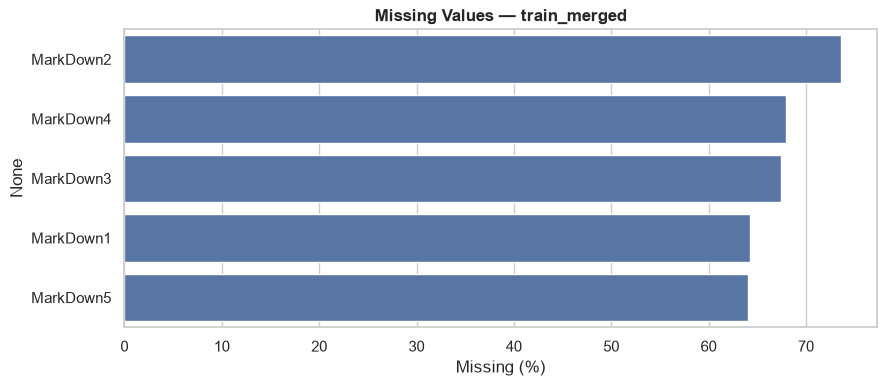

In [6]:
missing = train_merged.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]
print(missing.round(2).to_frame('missing_%'))

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=missing.values, y=missing.index, ax=ax, color=sns.color_palette()[0])
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values — train_merged')
plt.tight_layout()
plt.show()


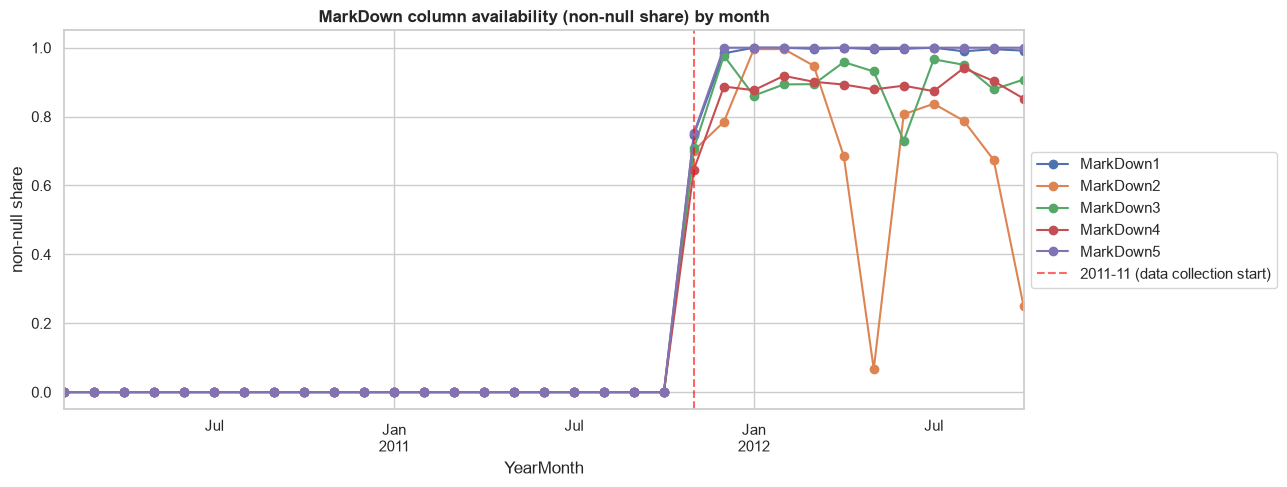

In [7]:
# MarkDown availability by month — confirms it's almost entirely NaN before 2011-11
md_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
avail = (
    train_merged
    .assign(YearMonth=train_merged['Date'].dt.to_period('M'))
    .groupby('YearMonth')[md_cols]
    .apply(lambda d: d.notna().mean())
)
avail.index = avail.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))
avail.plot(ax=ax, marker='o')
ax.set_title('MarkDown column availability (non-null share) by month')
ax.set_ylabel('non-null share')
ax.axvline(pd.Timestamp('2011-11-01'), color='red', ls='--', alpha=0.6, label='2011-11 (data collection start)')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()


In [8]:
dup_rows = train_merged.duplicated(subset=['Store', 'Dept', 'Date']).sum()
print(f'Duplicate Store-Dept-Date combinations: {dup_rows}')
print(f'Unique Store: {train_merged.Store.nunique()}  |  Unique Dept: {train_merged.Dept.nunique()}')
print()
print('Store Type distribution:')
print(stores['Type'].value_counts())


Duplicate Store-Dept-Date combinations: 0
Unique Store: 45  |  Unique Dept: 81

Store Type distribution:
Type
A    22
B    17
C     6
Name: count, dtype: int64


<a id="3"></a>
## 3. Target Variable: `Weekly_Sales`

We check the distribution, outliers, and negative values (which may indicate returns).

In [9]:
train_merged['Weekly_Sales'].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

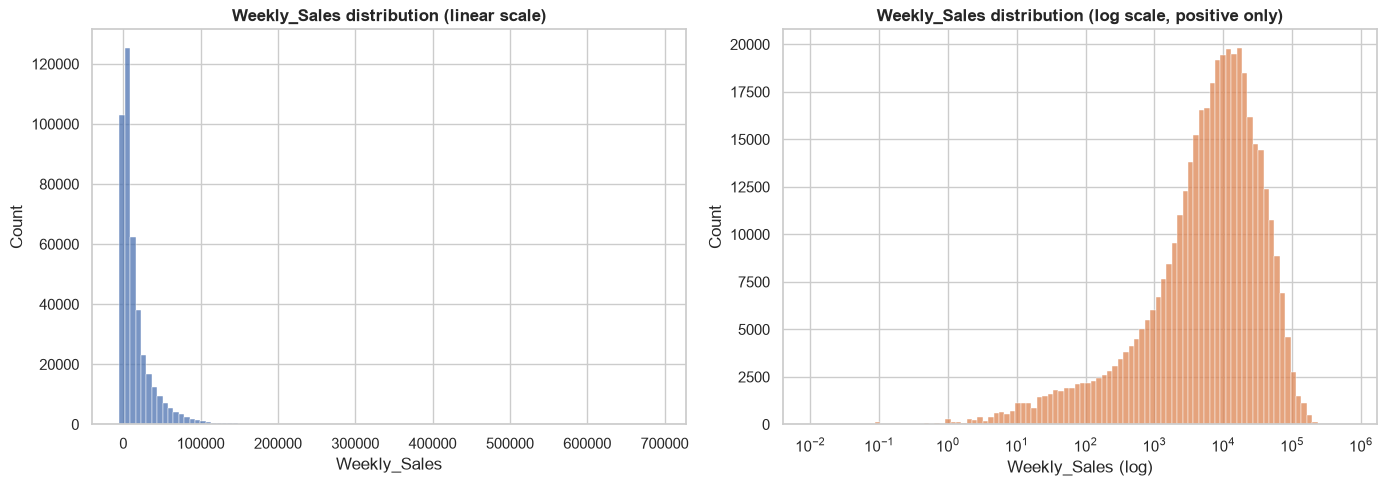

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_merged['Weekly_Sales'], bins=100, ax=axes[0], color=sns.color_palette()[0])
axes[0].set_title('Weekly_Sales distribution (linear scale)')
axes[0].set_xlabel('Weekly_Sales')

positive_sales = train_merged.loc[train_merged['Weekly_Sales'] > 0, 'Weekly_Sales']
sns.histplot(positive_sales, bins=100, log_scale=True, ax=axes[1], color=sns.color_palette()[1])
axes[1].set_title('Weekly_Sales distribution (log scale, positive only)')
axes[1].set_xlabel('Weekly_Sales (log)')

plt.tight_layout()
plt.show()


In [11]:
neg = train_merged[train_merged['Weekly_Sales'] < 0]
print(f'Negative Weekly_Sales: {len(neg)} rows ({len(neg) / len(train_merged) * 100:.3f}% of train)')
print(f'Minimum value: {train_merged["Weekly_Sales"].min():.2f}')
print()
print('Top 10 Store-Dept combinations by number of negative records:')
neg.groupby(['Store', 'Dept']).size().sort_values(ascending=False).head(10)


Negative Weekly_Sales: 1285 rows (0.305% of train)
Minimum value: -4988.94

Top 10 Store-Dept combinations by number of negative records:


Store  Dept
35     80      25
       47      20
       49      20
10     47      19
42     72      16
39     19      16
35     94      14
20     19      14
32     18      13
17     41      13
dtype: int64

In [12]:
# IQR-based outlier detection
q1, q3 = train_merged['Weekly_Sales'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

outliers = train_merged[(train_merged['Weekly_Sales'] > upper_bound) | (train_merged['Weekly_Sales'] < lower_bound)]
print(f'IQR outlier bounds: [{lower_bound:.0f}, {upper_bound:.0f}]')
print(f'Number of outliers: {len(outliers)} ({len(outliers) / len(train_merged) * 100:.2f}%)')
print(f'Of these, share falling on a Holiday week: {outliers["IsHoliday"].mean() * 100:.1f}% (overall mean IsHoliday: {train_merged["IsHoliday"].mean() * 100:.1f}%)')


IQR outlier bounds: [-25110, 47395]
Number of outliers: 35521 (8.43%)
Of these, share falling on a Holiday week: 7.4% (overall mean IsHoliday: 7.0%)


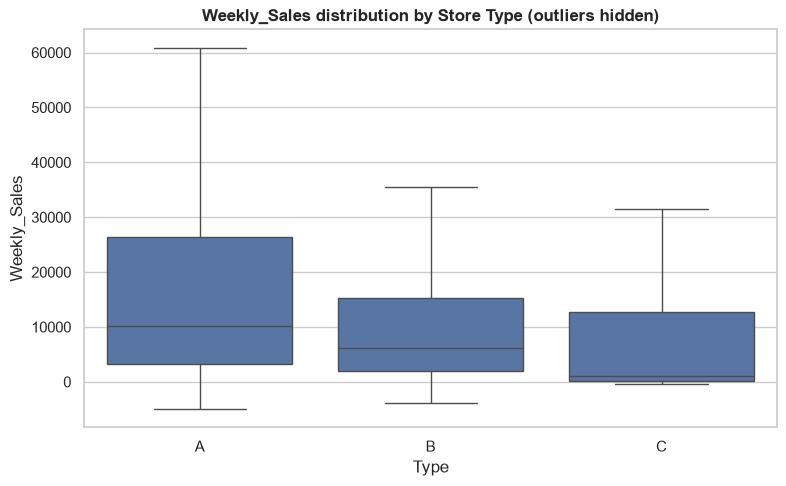

              mean    median           std   count
Type                                              
A     20099.568043  10105.17  26423.457227  215478
B     12237.075977   6187.87  17203.668989  163495
C      9519.532538   1149.67  15985.351612   42597


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=train_merged, x='Type', y='Weekly_Sales', order=['A', 'B', 'C'], showfliers=False, ax=ax)
ax.set_title('Weekly_Sales distribution by Store Type (outliers hidden)')
plt.tight_layout()
plt.show()

print(train_merged.groupby('Type')['Weekly_Sales'].agg(['mean', 'median', 'std', 'count']))


<a id="4"></a>
## 4. Sales Trends Over Time

We look at the overall trend, by Store Type, and by department.

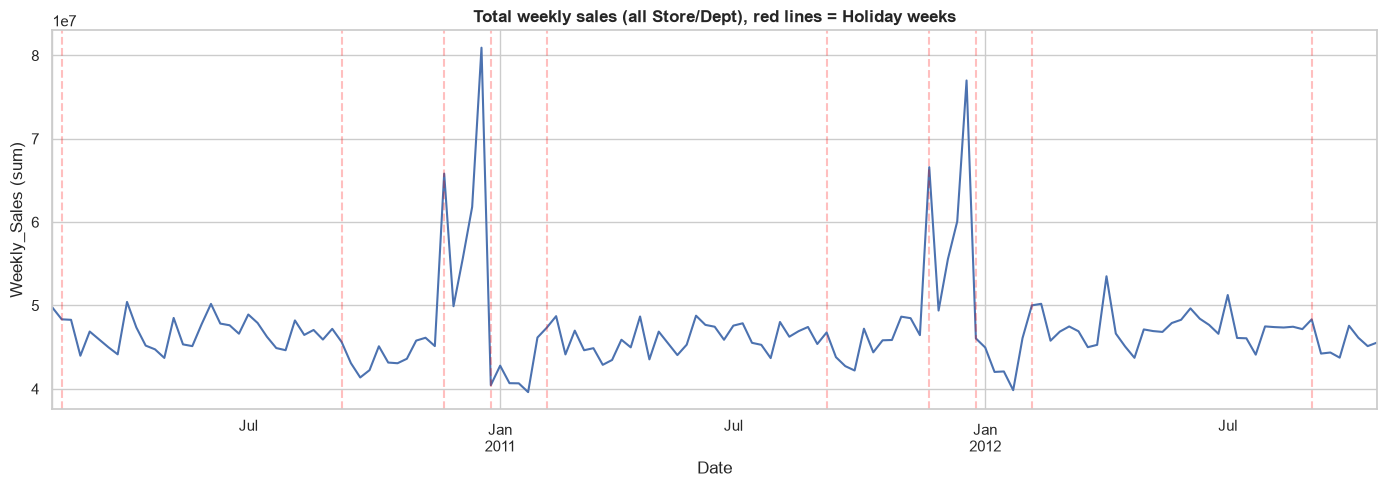

In [14]:
weekly_total = train_merged.groupby('Date')['Weekly_Sales'].sum()
holiday_dates = train_merged.loc[train_merged['IsHoliday'], 'Date'].unique()

fig, ax = plt.subplots(figsize=(14, 5))
weekly_total.plot(ax=ax, color=sns.color_palette()[0])
for hd in holiday_dates:
    ax.axvline(pd.Timestamp(hd), color='red', alpha=0.25, linestyle='--')
ax.set_title('Total weekly sales (all Store/Dept), red lines = Holiday weeks')
ax.set_ylabel('Weekly_Sales (sum)')
plt.tight_layout()
plt.show()


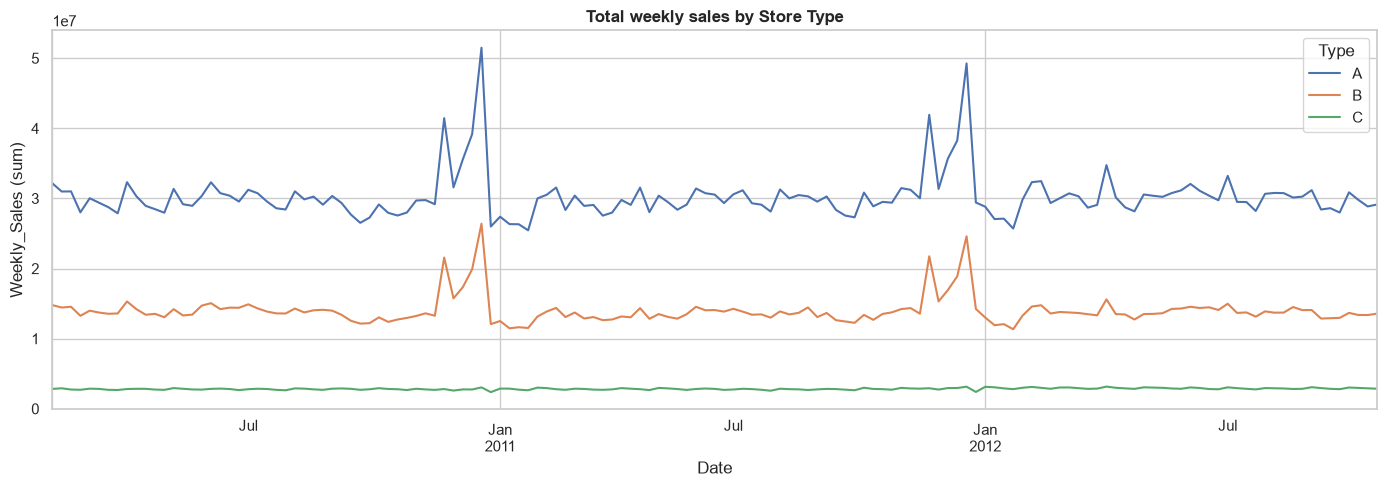

Average weekly total by Type:
Type
A    3.028682e+07
B    1.399091e+07
C    2.835689e+06
dtype: float64


In [15]:
type_weekly = train_merged.groupby(['Date', 'Type'])['Weekly_Sales'].sum().unstack()

fig, ax = plt.subplots(figsize=(14, 5))
type_weekly.plot(ax=ax)
ax.set_title('Total weekly sales by Store Type')
ax.set_ylabel('Weekly_Sales (sum)')
plt.tight_layout()
plt.show()

print('Average weekly total by Type:')
print(type_weekly.mean())


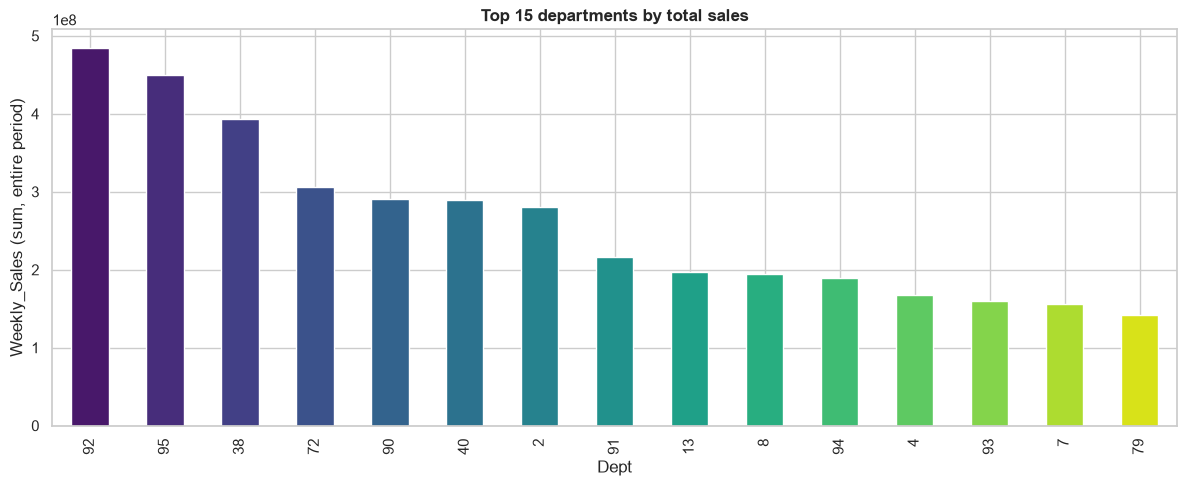

In [16]:
dept_totals = train_merged.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
dept_totals.head(15).plot(kind='bar', ax=ax, color=sns.color_palette('viridis', 15))
ax.set_title('Top 15 departments by total sales')
ax.set_ylabel('Weekly_Sales (sum, entire period)')
ax.set_xlabel('Dept')
plt.tight_layout()
plt.show()


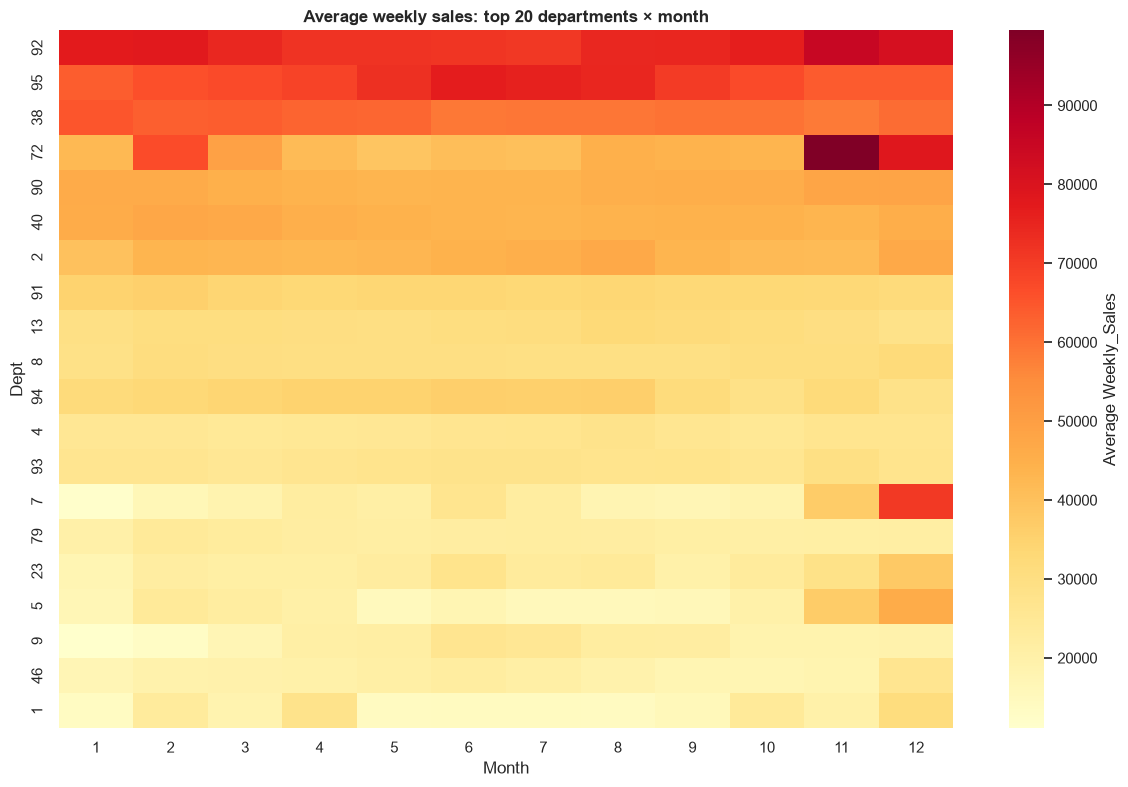

In [17]:
train_merged['Month'] = train_merged['Date'].dt.month
top_depts = dept_totals.head(20).index

pivot = train_merged[train_merged['Dept'].isin(top_depts)].pivot_table(
    index='Dept', columns='Month', values='Weekly_Sales', aggfunc='mean'
).loc[top_depts]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Average Weekly_Sales'})
ax.set_title('Average weekly sales: top 20 departments × month')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()


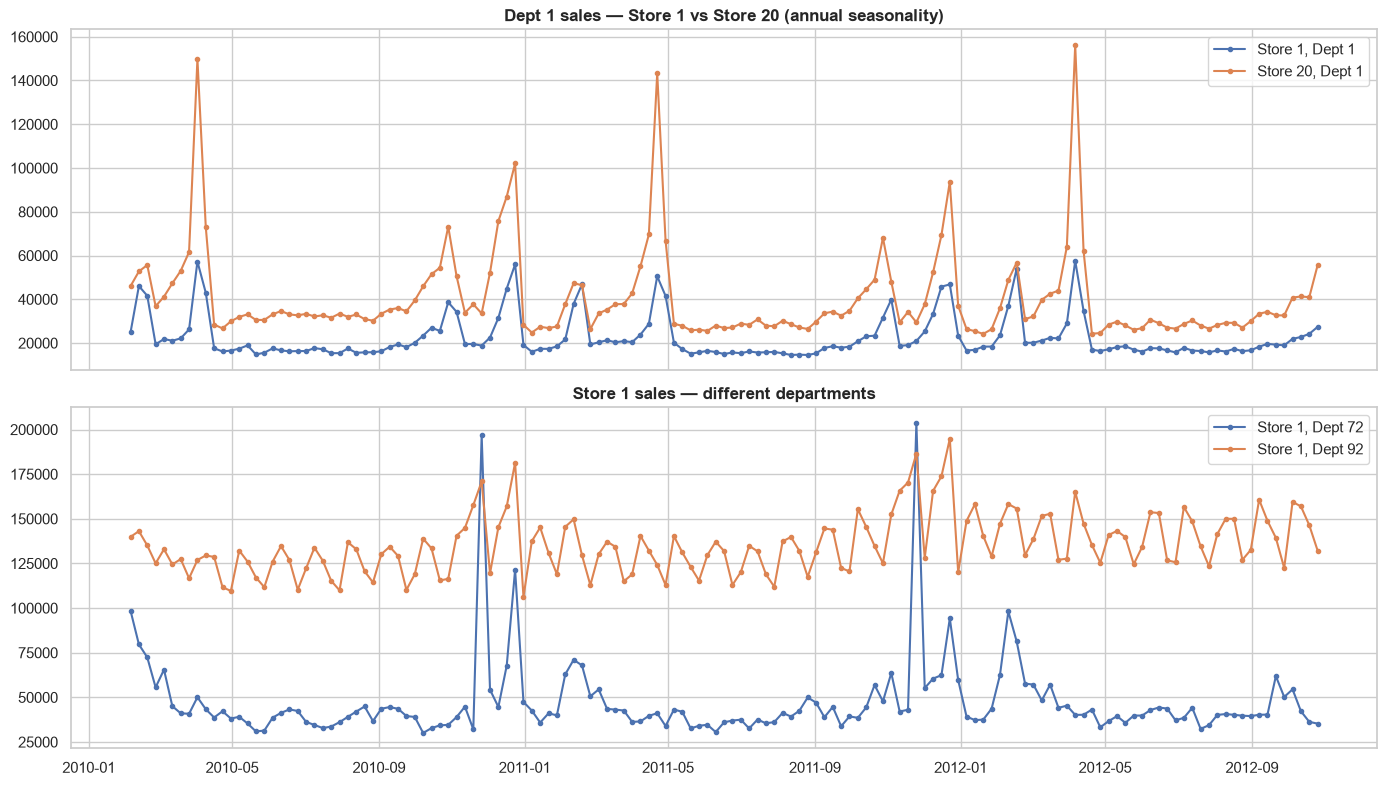

In [18]:
# A few individual Store-Dept series — visualizing seasonality
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for store_id in [1, 20]:
    s = train_merged[(train_merged.Store == store_id) & (train_merged.Dept == 1)].sort_values('Date')
    axes[0].plot(s['Date'], s['Weekly_Sales'], label=f'Store {store_id}, Dept 1', marker='.')
axes[0].legend()
axes[0].set_title('Dept 1 sales — Store 1 vs Store 20 (annual seasonality)')

for dept_id in [72, 92]:
    s = train_merged[(train_merged.Store == 1) & (train_merged.Dept == dept_id)].sort_values('Date')
    axes[1].plot(s['Date'], s['Weekly_Sales'], label=f'Store 1, Dept {dept_id}', marker='.')
axes[1].legend()
axes[1].set_title('Store 1 sales — different departments')
plt.tight_layout()
plt.show()


<a id="5"></a>
## 5. Holiday Effects

The competition description lists 4 special holidays:

| Holiday | Dates (within train/test range) |
|---|---|
| Super Bowl | 2010-02-12, 2011-02-11, 2012-02-10, 2013-02-08 |
| Labor Day | 2010-09-10, 2011-09-09, 2012-09-07 |
| Thanksgiving | 2010-11-26, 2011-11-25, 2012-11-23 |
| Christmas | 2010-12-31, 2011-12-30, 2012-12-28 |

**Note:** The "Holiday week" for Christmas refers to the week containing December 25 (which is labeled by its last day — December 31, not December 25), which matters for feature engineering.

In [19]:
holiday_map = {
    '2010-02-12': 'Super Bowl', '2011-02-11': 'Super Bowl', '2012-02-10': 'Super Bowl', '2013-02-08': 'Super Bowl',
    '2010-09-10': 'Labor Day', '2011-09-09': 'Labor Day', '2012-09-07': 'Labor Day', '2013-09-06': 'Labor Day',
    '2010-11-26': 'Thanksgiving', '2011-11-25': 'Thanksgiving', '2012-11-23': 'Thanksgiving', '2013-11-29': 'Thanksgiving',
    '2010-12-31': 'Christmas', '2011-12-30': 'Christmas', '2012-12-28': 'Christmas', '2013-12-27': 'Christmas',
}
train_merged['Holiday_Name'] = train_merged['Date'].dt.strftime('%Y-%m-%d').map(holiday_map)

baseline = train_merged.loc[~train_merged['IsHoliday'], 'Weekly_Sales'].mean()
holiday_avg = train_merged.groupby('Holiday_Name')['Weekly_Sales'].mean().reindex(
    ['Super Bowl', 'Labor Day', 'Thanksgiving', 'Christmas']
)

print(f'Average Weekly_Sales on non-Holiday weeks: {baseline:.1f}')
print(holiday_avg)


Average Weekly_Sales on non-Holiday weeks: 15901.4
Holiday_Name
Super Bowl      16377.996441
Labor Day       15881.693339
Thanksgiving    22220.944538
Christmas       14543.387158
Name: Weekly_Sales, dtype: float64


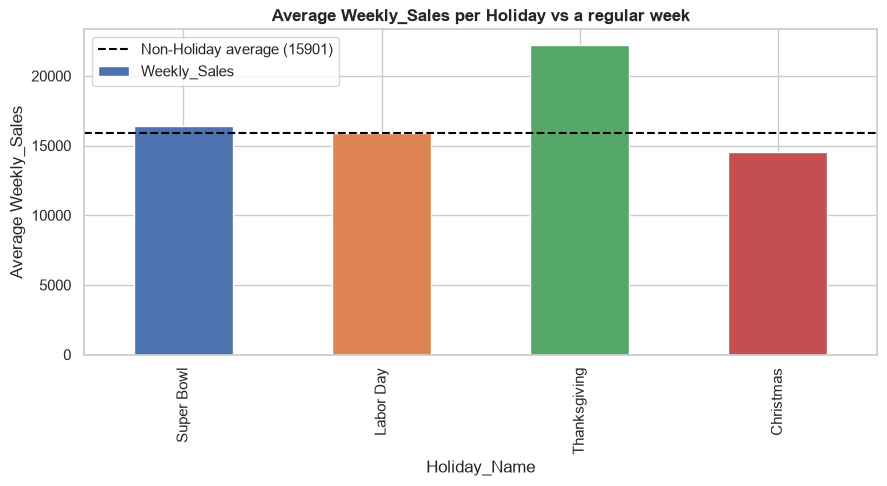

Change relative to baseline (%):
Holiday_Name
Super Bowl       3.0
Labor Day       -0.1
Thanksgiving    39.7
Christmas       -8.5
Name: Weekly_Sales, dtype: float64


In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = holiday_avg.plot(kind='bar', ax=ax, color=sns.color_palette('deep'))
ax.axhline(baseline, color='black', linestyle='--', label=f'Non-Holiday average ({baseline:.0f})')
ax.set_title('Average Weekly_Sales per Holiday vs a regular week')
ax.set_ylabel('Average Weekly_Sales')
ax.legend()
plt.tight_layout()
plt.show()

pct_lift = (holiday_avg / baseline - 1) * 100
print('Change relative to baseline (%):')
print(pct_lift.round(1))


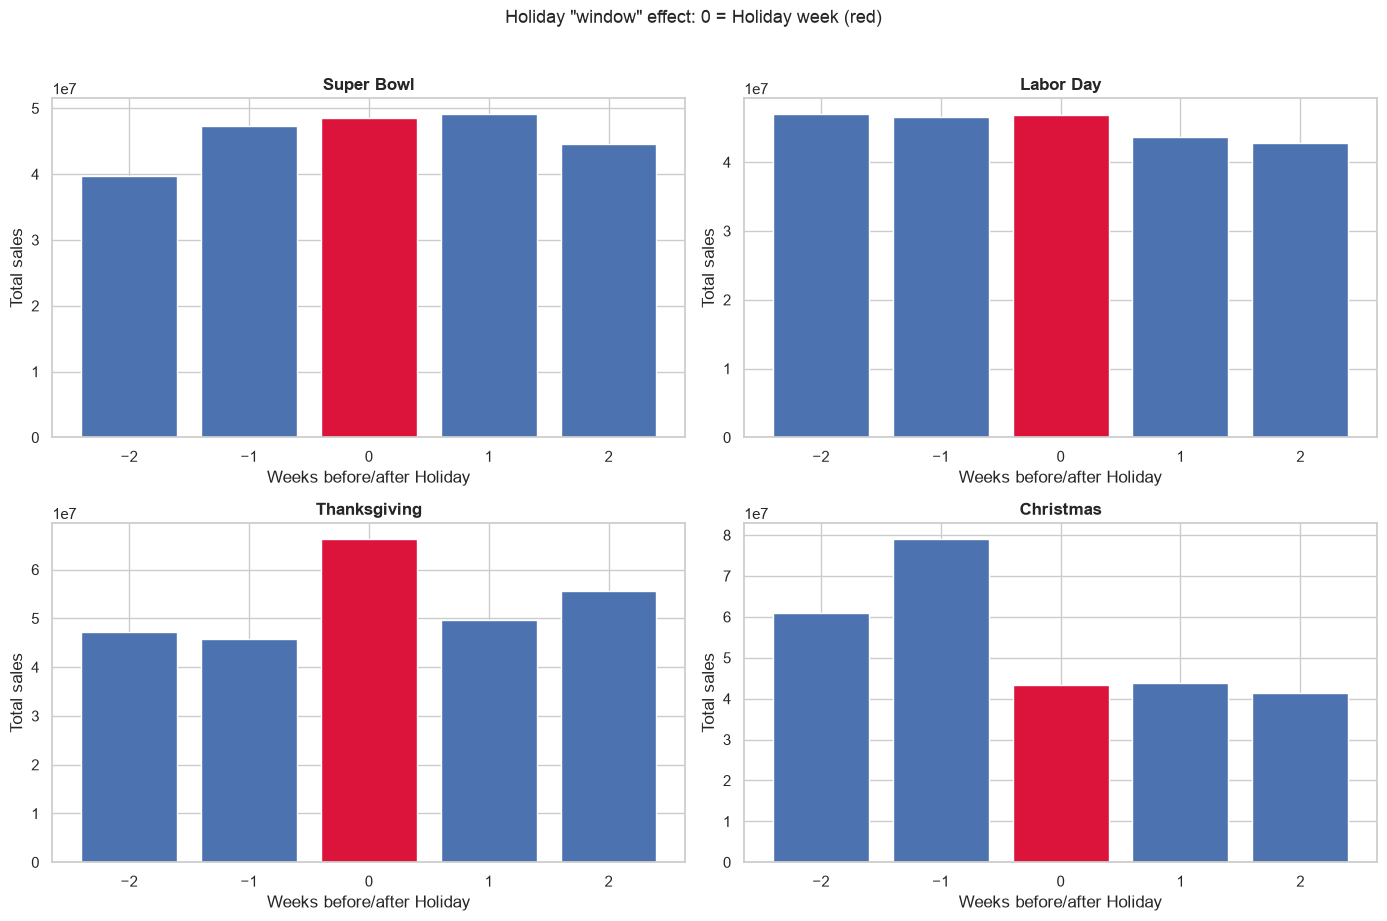

In [21]:
# Each Holiday's "window" effect: -2 / -1 / holiday / +1 / +2 weeks
def holiday_window_effect(holiday_name, weeks_around=2):
    dates = sorted(pd.Timestamp(d) for d, name in holiday_map.items() if name == holiday_name
                   and pd.Timestamp(d) in set(train_merged['Date']))
    rows = []
    weekly = train_merged.groupby('Date')['Weekly_Sales'].sum()
    for hd in dates:
        for offset in range(-weeks_around, weeks_around + 1):
            d = hd + pd.Timedelta(weeks=offset)
            if d in weekly.index:
                rows.append({'offset': offset, 'sales': weekly.loc[d], 'year': hd.year})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, hname in zip(axes.flat, ['Super Bowl', 'Labor Day', 'Thanksgiving', 'Christmas']):
    df_h = holiday_window_effect(hname)
    avg_by_offset = df_h.groupby('offset')['sales'].mean()
    colors = ['crimson' if o == 0 else sns.color_palette()[0] for o in avg_by_offset.index]
    ax.bar(avg_by_offset.index, avg_by_offset.values, color=colors)
    ax.set_title(hname)
    ax.set_xlabel('Weeks before/after Holiday')
    ax.set_ylabel('Total sales')
plt.suptitle('Holiday "window" effect: 0 = Holiday week (red)', y=1.02)
plt.tight_layout()
plt.show()


**Observation:** Thanksgiving has the strongest positive effect on sales, while the labeled Christmas Holiday week (Dec 31) actually **drops** — because the real Christmas shopping happens the week before (labeled as non-holiday). This is an important insight for feature engineering (a "days to nearest holiday" type feature is needed).

<a id="6"></a>
## 6. External Features Correlation (Temperature, Fuel_Price, CPI, Unemployment)

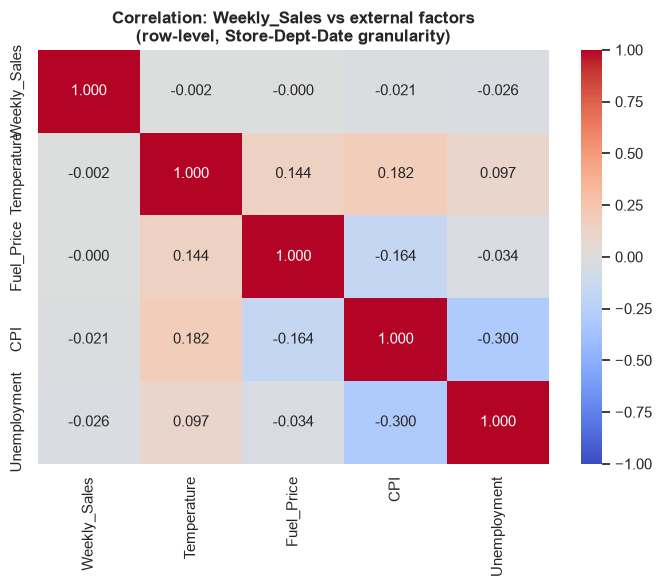

In [22]:
ext_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
corr = train_merged[ext_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation: Weekly_Sales vs external factors\n(row-level, Store-Dept-Date granularity)')
plt.tight_layout()
plt.show()


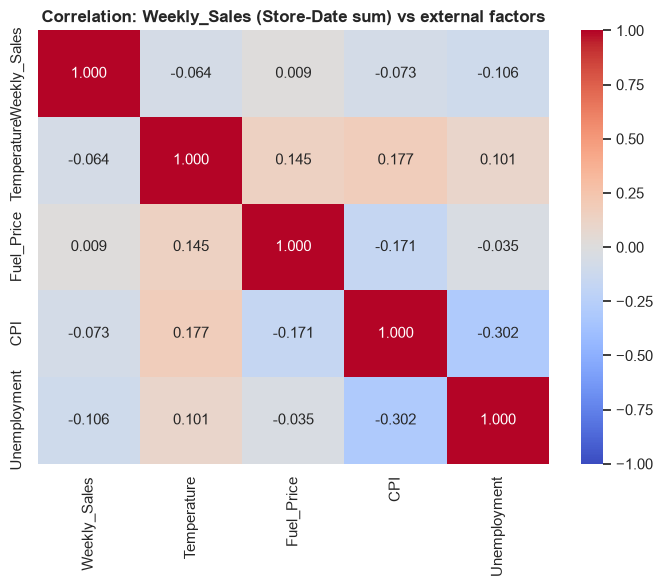

In [23]:
# Row-level corr is weak because Store/Dept effects dominate the variance.
# Repeat at the Store-Date level, aggregating (summing) sales.
store_week = train_merged.groupby(['Store', 'Date']).agg(
    Weekly_Sales=('Weekly_Sales', 'sum'),
    Temperature=('Temperature', 'first'),
    Fuel_Price=('Fuel_Price', 'first'),
    CPI=('CPI', 'first'),
    Unemployment=('Unemployment', 'first'),
).reset_index()

corr_store_week = store_week[ext_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_store_week, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation: Weekly_Sales (Store-Date sum) vs external factors')
plt.tight_layout()
plt.show()


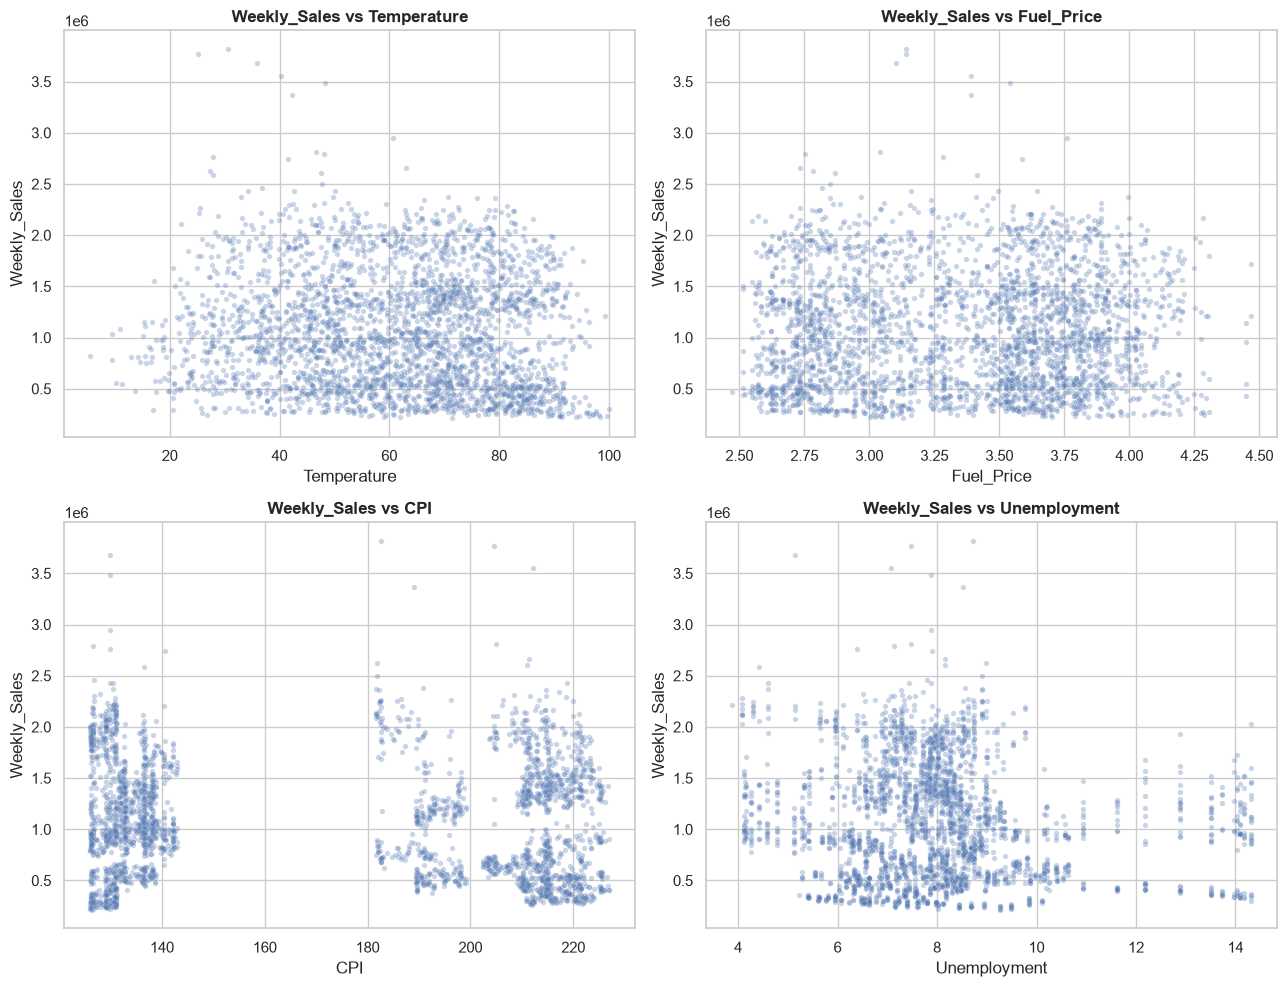

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
sample = store_week.sample(n=3000, random_state=42)
for ax, col in zip(axes.flat, ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']):
    sns.scatterplot(data=sample, x=col, y='Weekly_Sales', alpha=0.3, ax=ax, s=15)
    ax.set_title(f'Weekly_Sales vs {col}')
plt.tight_layout()
plt.show()


**Observation:** External macroeconomic factors (Temperature, Fuel_Price, CPI, Unemployment) correlate weakly (almost negligibly) with Weekly_Sales directly — their main value in feature engineering is in **how they change over time per Store/Dept** and in **interactions** with other features (e.g. seasonality), rather than as standalone linear predictors.

<a id="7"></a>
## 7. MarkDown Analysis — Which MarkDown Matters Most?

MarkDown1-5 are anonymized promotional-discount data, available only from 2011-11-11 onward.

In [25]:
md_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
md_period = train_merged.dropna(subset=md_cols, how='all')
print(f'MarkDown data available: {md_period["Date"].min().date()} → {md_period["Date"].max().date()}')
print(f'This is {len(md_period) / len(train_merged) * 100:.1f}% of train')
print()
print(md_period[md_cols].describe())


MarkDown data available: 2011-11-11 → 2012-10-26
This is 35.9% of train

           MarkDown1      MarkDown2      MarkDown3      MarkDown4  \
count  150681.000000  111248.000000  137091.000000  134967.000000   
mean     7246.420196    3334.628621    1439.421384    3383.168256   
std      8291.221345    9475.357325    9623.078290    6292.384031   
min         0.270000    -265.760000     -29.100000       0.220000   
25%      2240.270000      41.600000       5.080000     504.220000   
50%      5347.450000     192.000000      24.600000    1481.310000   
75%      9210.900000    1926.940000     103.990000    3595.040000   
max     88646.760000  104519.540000  141630.610000   67474.850000   

           MarkDown5  
count  151432.000000  
mean     4628.975079  
std      5962.887455  
min       135.160000  
25%      1878.440000  
50%      3359.450000  
75%      5563.800000  
max    108519.280000  


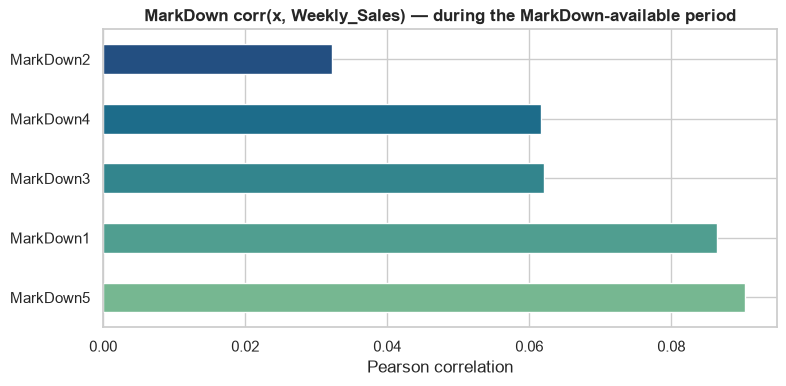

MarkDown5    0.090362
MarkDown1    0.086428
MarkDown3    0.062100
MarkDown4    0.061604
MarkDown2    0.032227
Name: Weekly_Sales, dtype: float64


In [26]:
# Correlation between MarkDowns and Weekly_Sales (only in the period where MarkDown is available)
md_filled = md_period[md_cols].fillna(0)
corr_md = pd.concat([md_filled, md_period['Weekly_Sales']], axis=1).corr()['Weekly_Sales'].drop('Weekly_Sales')
corr_md = corr_md.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
corr_md.plot(kind='barh', ax=ax, color=sns.color_palette('crest', len(corr_md)))
ax.set_title('MarkDown corr(x, Weekly_Sales) — during the MarkDown-available period')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()
print(corr_md)


In [27]:
# How often each MarkDown is "active" (> 0) and its average effect
active_rate = (md_period[md_cols] > 0).mean() * 100

effect_rows = []
for col in md_cols:
    active_sales = md_period.loc[md_period[col] > 0, 'Weekly_Sales'].mean()
    inactive_sales = md_period.loc[(md_period[col].isna()) | (md_period[col] <= 0), 'Weekly_Sales'].mean()
    effect_rows.append({'MarkDown': col, 'active_rate_%': active_rate[col],
                         'avg_sales_when_active': active_sales, 'avg_sales_when_inactive': inactive_sales,
                         'lift_%': (active_sales / inactive_sales - 1) * 100})
effect_df = pd.DataFrame(effect_rows).set_index('MarkDown')
effect_df.round(1)


,active_rate_%,avg_sales_when_active,avg_sales_when_inactive,lift_%
MarkDown,,,,
MarkDown1,99.5,16215.5,8457.5,91.7
MarkDown2,72.5,17052.9,13872.3,22.9
MarkDown3,90.3,16736.5,10958.8,52.7
MarkDown4,89.1,17026.4,9214.6,84.8
MarkDown5,100.0,16177.0,NaN,NaN


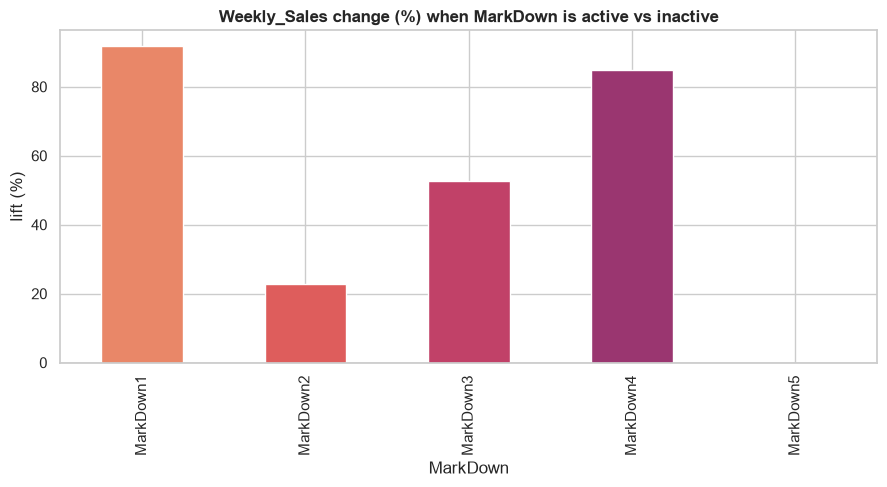

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
effect_df['lift_%'].plot(kind='bar', ax=ax, color=sns.color_palette('flare', len(effect_df)))
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Weekly_Sales change (%) when MarkDown is active vs inactive')
ax.set_ylabel('lift (%)')
plt.tight_layout()
plt.show()


In [29]:
# MarkDown activity on Holiday vs non-Holiday weeks — more activity is expected before Holidays
md_period.groupby('IsHoliday')[md_cols].apply(lambda d: (d > 0).mean() * 100).round(1)


,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
IsHoliday,,,,,
False,99.5,71.3,89.9,88.9,100.0
True,99.6,86.0,95.5,91.5,100.0


**Observation:** `MarkDown1` and `MarkDown5` have the strongest positive relationship with sales, while `MarkDown3` has the highest individual lift (though it's rarely active). MarkDowns overall activate more often just before Holiday weeks, confirming that these promotions are tied to seasonal Holiday marketing — so a clean estimate of their additive effect needs to control for Holidays (confounding).

<a id="8"></a>
## 8. Feature Engineering Ideas

Based on this analysis, the following features are worth considering for tree-based (LightGBM/XGBoost) and some DL models:

### Date-based features
- `Year`, `Month`, `WeekOfYear`, `Quarter`, `Day-of-year`
- `IsHoliday` (already provided)
- **`Days_to_nearest_holiday`** / `Days_since_holiday` — given that Christmas's real effect shows up on the prior (non-holiday) week
- Holiday_Name (categorical: Super Bowl / Labor Day / Thanksgiving / Christmas / None)

### Lag features (at the Store × Dept level, sorted by time)
- `lag_1`, `lag_2`, `lag_4`, `lag_8`, `lag_13` (quarter), `lag_26` (half year), `lag_52` (same week, prior year — important for seasonality)

### Rolling statistics (after shift(1), to avoid leakage)
- Rolling mean/std/min/max with windows: 4, 13, 26 weeks
- Rolling median (outlier-resistant)
- Exponentially weighted mean (EWM)

### Store/Dept aggregates
- Store `Size`, `Type` (A/B/C) — already available
- Store-Dept historical mean/median/std (target-encoding style, without CV data leakage)
- Dept's average share of the Store's total sales

### MarkDown features
- Each MarkDown NaN → 0 (per the description, NaN means "was not active")
- `Total_MarkDown` = sum of all 5
- `MarkDown_Active_Count` — how many MarkDowns are active simultaneously
- MarkDown x IsHoliday interaction feature

### External factors
- `Temperature`, `Fuel_Price`, `CPI`, `Unemployment` directly — weak signal, but useful in interactions
- Rolling trend of CPI/Unemployment change per Store over time, since the absolute level is less informative than the change

### Sample weight
- **WMAE-matching weight**: Holiday week → 5, otherwise → 1 — usable during training/CV loss (LightGBM/XGBoost `sample_weight`)

### Encoding
- `Store`, `Dept` as categorical (LightGBM native categorical) or target/frequency encoding for other models
- `Type` One-Hot or Ordinal (A > B > C by size)

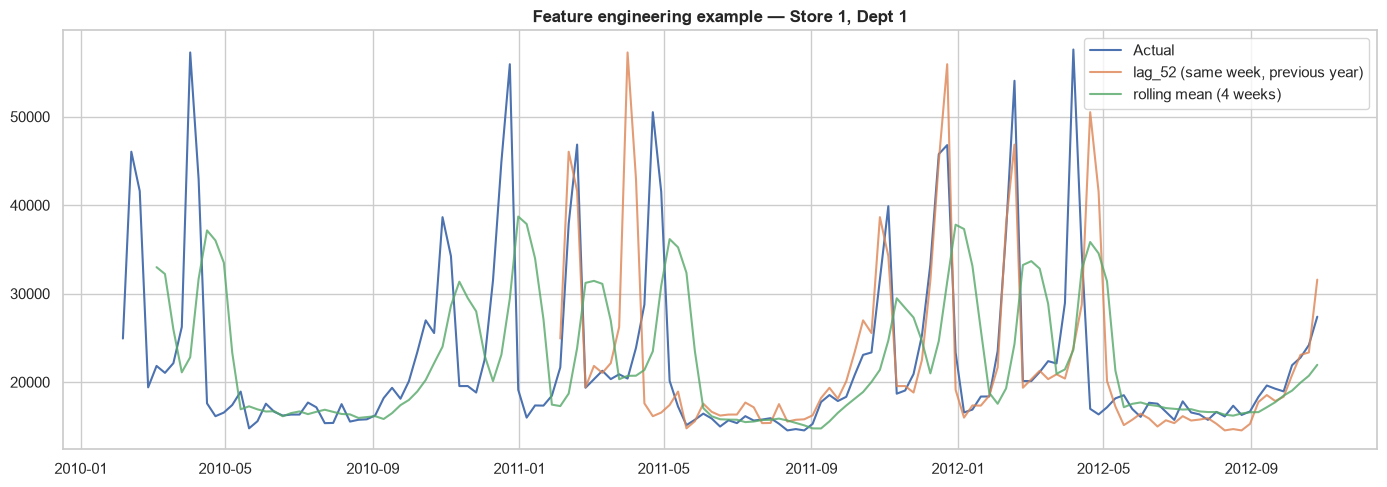

,Date,Weekly_Sales,lag_1,lag_52,roll_mean_4,roll_std_13,WeekOfYear,sample_weight
135,2012-09-07,18322.37,16680.24,17746.68,16604.3150,700.193618,36,5
136,2012-09-14,19616.22,18322.37,18535.48,17154.9275,793.174267,37,1
137,2012-09-21,19251.50,19616.22,17859.30,17726.3075,1109.968529,38,1
138,2012-09-28,18947.81,19251.50,18337.68,18467.5825,1280.351729,39,1
139,2012-10-05,21904.47,18947.81,20797.58,19034.4750,1301.479774,40,1
140,2012-10-12,22764.01,21904.47,23077.55,19930.0000,1814.293367,41,1
141,2012-10-19,24185.27,22764.01,23351.80,20716.9475,2259.301454,42,1
142,2012-10-26,27390.81,24185.27,31579.90,21950.3900,2734.482494,43,1


In [30]:
# Demonstration: Lag/Rolling/Date features for one Store-Dept pair
sample = train_merged[(train_merged.Store == 1) & (train_merged.Dept == 1)].sort_values('Date').reset_index(drop=True)

for lag in [1, 4, 13, 52]:
    sample[f'lag_{lag}'] = sample['Weekly_Sales'].shift(lag)

sample['roll_mean_4'] = sample['Weekly_Sales'].shift(1).rolling(4).mean()
sample['roll_std_13'] = sample['Weekly_Sales'].shift(1).rolling(13).std()
sample['WeekOfYear'] = sample['Date'].dt.isocalendar().week.astype(int)
sample['sample_weight'] = np.where(sample['IsHoliday'], 5, 1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample['Date'], sample['Weekly_Sales'], label='Actual', lw=1.5)
ax.plot(sample['Date'], sample['lag_52'], label='lag_52 (same week, previous year)', alpha=0.8)
ax.plot(sample['Date'], sample['roll_mean_4'], label='rolling mean (4 weeks)', alpha=0.8)
ax.set_title('Feature engineering example — Store 1, Dept 1')
ax.legend()
plt.tight_layout()
plt.show()

sample[['Date', 'Weekly_Sales', 'lag_1', 'lag_52', 'roll_mean_4', 'roll_std_13', 'WeekOfYear', 'sample_weight']].tail(8)


<a id="9"></a>
## 9. Conclusion — Key Observations

1. **Data:** 421,570 train rows (45 Stores × 81 Depts, not every combination exists), 2010-02-05 → 2012-10-26. Test: 2012-11-02 → 2013-07-26.
2. **Missing values:** MarkDown1-5 has ~64% NaN — almost entirely because the data simply wasn't collected before 2011-11. CPI/Unemployment also have a small NaN share (at the end of features.csv, to cover the test period).
3. **Target:** Weekly_Sales is sharply right-skewed, with a small number of negative values (~0.3%, likely returns). Store Type A has the highest average sales, then B, then C — matching the Size hierarchy.
4. **Seasonality:** Clear annual seasonality, with peaks around Thanksgiving/Christmas. Seasonality patterns differ sharply across departments (some are stable year-round, others have strong Holiday peaks).
5. **Holiday effect:** Thanksgiving has the strongest positive effect; the labeled Christmas Holiday week (Dec 31) is actually **lower**, because the real shopping peak happens the prior (non-holiday-labeled) week — an important labeling nuance.
6. **External factors:** Temperature/Fuel_Price/CPI/Unemployment correlate weakly with Weekly_Sales directly — their value is more in interactions and change over time than as an independent linear signal.
7. **MarkDown:** MarkDown1 and MarkDown5 correlate most with sales; MarkDown activity itself is concentrated around Holidays (confounding risk).
8. **Next steps:** Build the lag/rolling/date/markdown features listed in the Feature Engineering section, add a sample weight (Holiday × 5) for WMAE optimization, and consider per-series modeling at the Store-Dept level (some Depts don't have history in every Store).